# Customer Support Ticket Analytics System
## Response Time Analytics

**Input:** `NLP_enriched_tickets.csv` (200,000 rows, 40 columns)  
**Focus Metrics:** `first_response_time_hours`, `resolution_time_hours`, `sla_breached`, `escalated`



---
## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'xtick.labelsize': 9})

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
print('Setup complete')

Setup complete


---
## 2. Load Data

In [2]:
df = pd.read_csv('C:/Users/Tarun/OneDrive/Desktop/Project 3/Data Sets/NLP_enriched_tickets.csv', parse_dates=['ticket_created_date', 'ticket_resolved_date'])
df['complexity_bucket'] = pd.cut(
    df['issue_complexity_score'],
    bins=[0, 3, 6, 10],
    labels=['Low (1-3)', 'Mid (4-6)', 'High (7-10)']
)

df_resolved = df[df['status'].isin(['Closed', 'Resolved'])].copy()

print(f'Full dataset  : {df.shape}')
print(f'Resolved only : {df_resolved.shape}')
print(f'\nSLA Breach rate : {df["sla_breached"].mean():.1%}')
print(f'Escalation rate : {df["escalated"].mean():.1%}')
print(f'\nAvg first response : {df["first_response_time_hours"].mean():.1f} hrs')
print(f'Avg resolution     : {df["resolution_time_hours"].mean():.1f} hrs ({df["resolution_time_hours"].mean()/24:.1f} days)')

Full dataset  : (200000, 41)
Resolved only : (79999, 41)

SLA Breach rate : 50.0%
Escalation rate : 50.2%

Avg first response : 36.3 hrs
Avg resolution     : 120.5 hrs (5.0 days)


---
## 3. Response & Resolution Time Distributions

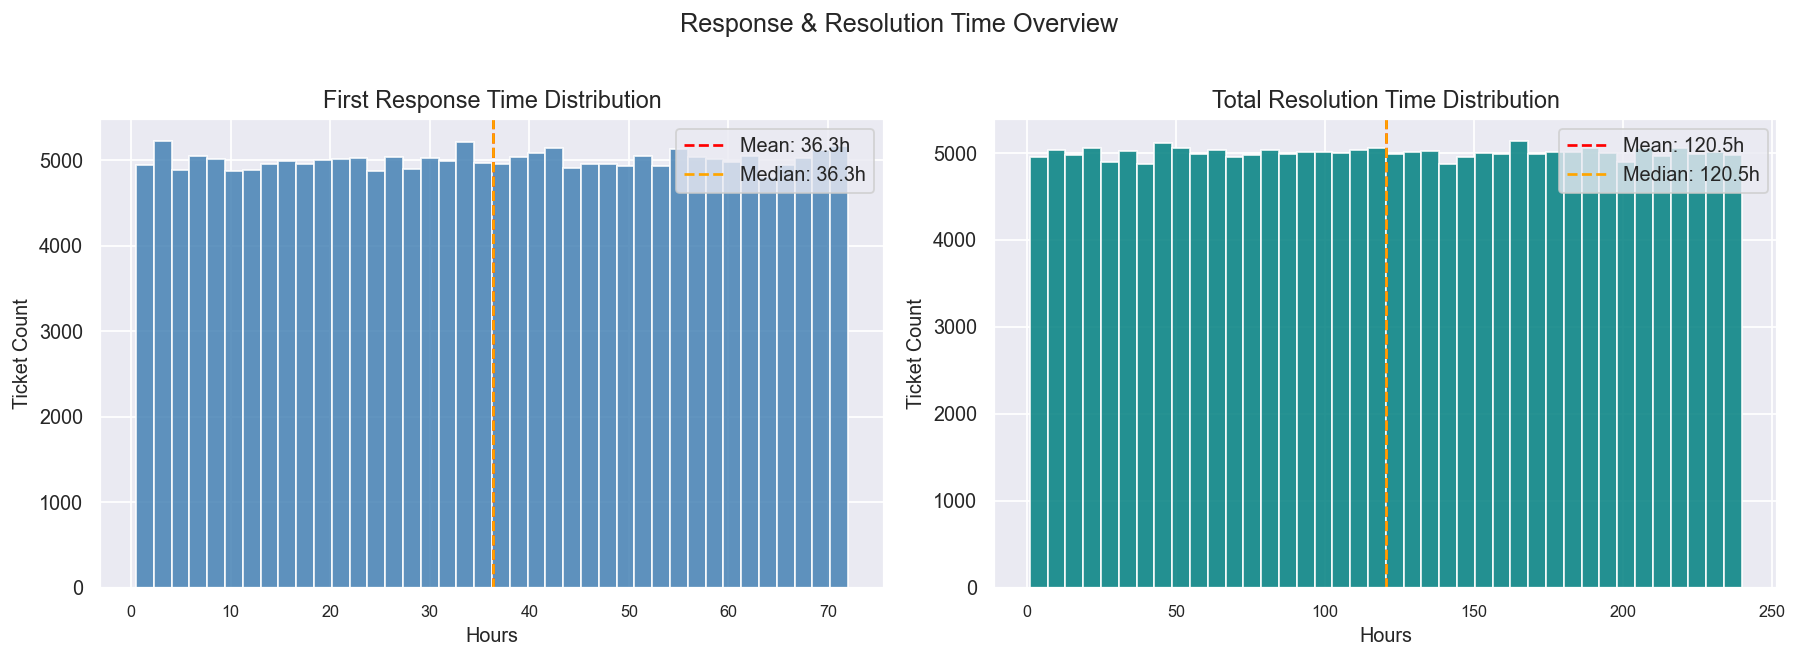

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# First response time histogram
axes[0].hist(df['first_response_time_hours'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['first_response_time_hours'].mean(), color='red', linestyle='--', label=f'Mean: {df["first_response_time_hours"].mean():.1f}h')
axes[0].axvline(df['first_response_time_hours'].median(), color='orange', linestyle='--', label=f'Median: {df["first_response_time_hours"].median():.1f}h')
axes[0].set_title('First Response Time Distribution')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Ticket Count')
axes[0].legend()

# Resolution time histogram
axes[1].hist(df['resolution_time_hours'], bins=40, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(df['resolution_time_hours'].mean(), color='red', linestyle='--', label=f'Mean: {df["resolution_time_hours"].mean():.1f}h')
axes[1].axvline(df['resolution_time_hours'].median(), color='orange', linestyle='--', label=f'Median: {df["resolution_time_hours"].median():.1f}h')
axes[1].set_title('Total Resolution Time Distribution')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Ticket Count')
axes[1].legend()

plt.suptitle('Response & Resolution Time Overview', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [4]:
# Percentile table — useful for SLA threshold setting
pct_labels = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

pct_df = pd.DataFrame({
    'Percentile': [f'{int(p*100)}th' for p in pct_labels],
    'First Response (hrs)': df['first_response_time_hours'].quantile(pct_labels).values.round(1),
    'Resolution Time (hrs)': df['resolution_time_hours'].quantile(pct_labels).values.round(1),
    'Resolution Time (days)': (df['resolution_time_hours'].quantile(pct_labels).values / 24).round(1)
})
pct_df

,Percentile,First Response (hrs),Resolution Time (hrs),Resolution Time (days)
0,25th,18.50,60.80,2.50
1,50th,36.30,120.40,5.00
2,75th,54.20,180.30,7.50
3,90th,65.00,216.10,9.00
4,95th,68.50,228.00,9.50
5,99th,71.30,237.60,9.90


---
## 4. SLA Breach Analysis

Overall SLA breach rate is ~50%. We break it down across every key dimension to identify *where* breaches cluster.

In [5]:
def breach_summary(df, group_col):
    """Returns breach rate, avg response time, and ticket count per group."""
    return (
        df.groupby(group_col)
        .agg(
            ticket_count=('ticket_id', 'count'),
            sla_breach_rate=('sla_breached', 'mean'),
            avg_first_response_hrs=('first_response_time_hours', 'mean'),
            avg_resolution_hrs=('resolution_time_hours', 'mean')
        )
        .assign(
            sla_breach_rate=lambda x: x['sla_breach_rate'].round(4),
            avg_first_response_hrs=lambda x: x['avg_first_response_hrs'].round(2),
            avg_resolution_hrs=lambda x: x['avg_resolution_hrs'].round(2)
        )
        .sort_values('sla_breach_rate', ascending=False)
    )

dims = ['priority', 'channel', 'category', 'region', 'subscription_type']
for d in dims:
    print(f'\n=== SLA Breach by {d.upper()} ===')
    print(breach_summary(df, d).to_string())


=== SLA Breach by PRIORITY ===
          ticket_count  sla_breach_rate  avg_first_response_hrs  avg_resolution_hrs
priority                                                                           
Low              49762             0.50                   36.36              121.03
Medium           49854             0.50                   36.36              120.15
High             50241             0.50                   36.31              120.28
Urgent           50143             0.50                   36.21              120.71

=== SLA Breach by CHANNEL ===
              ticket_count  sla_breach_rate  avg_first_response_hrs  avg_resolution_hrs
channel                                                                                
Email                39726             0.50                   36.14              120.66
Social Media         40038             0.50                   36.42              120.59
Chat                 40073             0.50                   36.37              

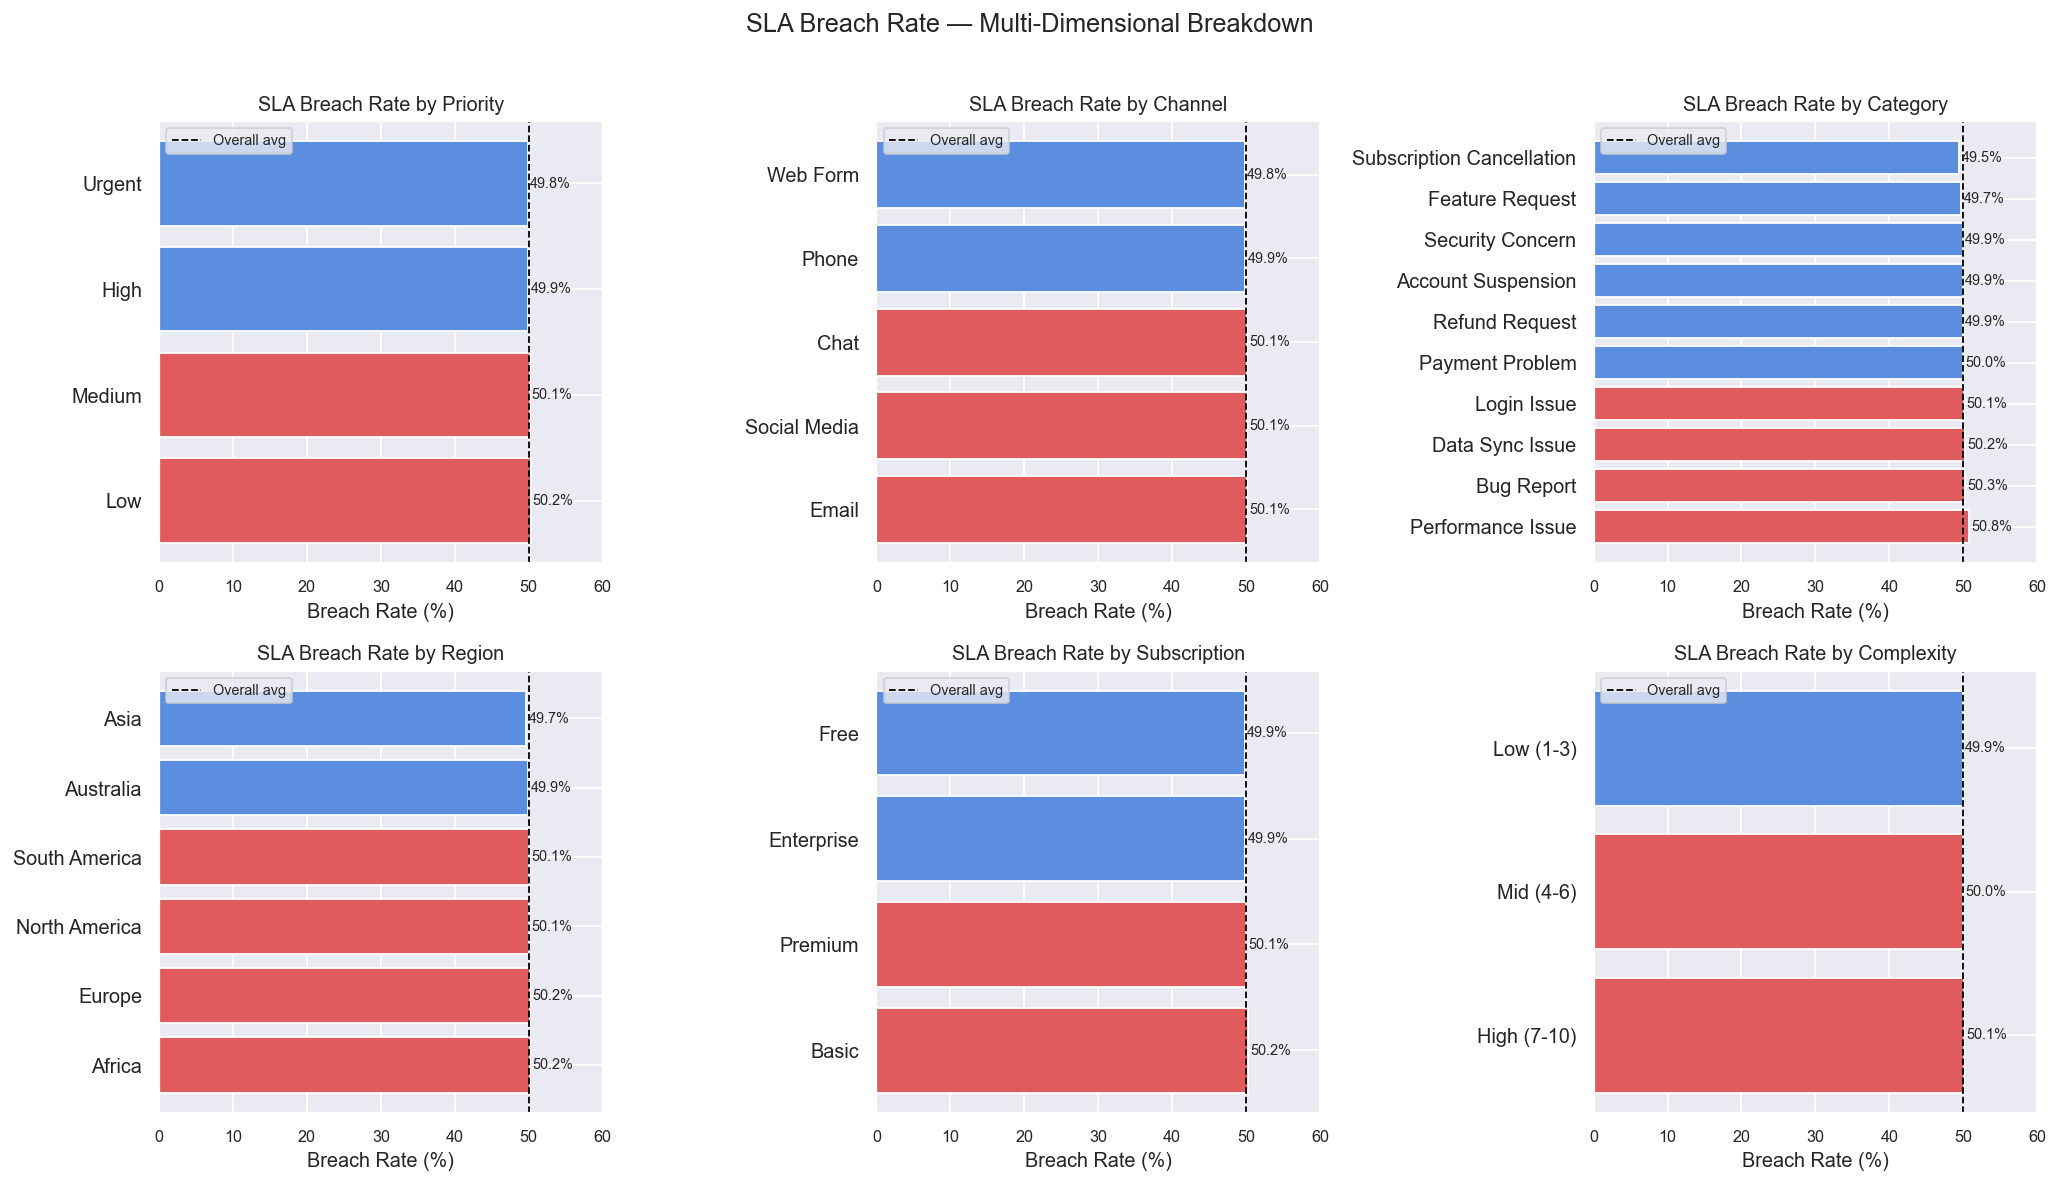

In [6]:
# Visual — SLA breach rate across 5 dimensions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

dims_plot = [
    ('priority',          'SLA Breach Rate by Priority'),
    ('channel',           'SLA Breach Rate by Channel'),
    ('category',          'SLA Breach Rate by Category'),
    ('region',            'SLA Breach Rate by Region'),
    ('subscription_type', 'SLA Breach Rate by Subscription'),
    ('complexity_bucket', 'SLA Breach Rate by Complexity'),
]

for ax, (col, title) in zip(axes, dims_plot):
    data = df.groupby(col, observed=True)['sla_breached'].mean().sort_values(ascending=False)
    colors = ['#e05c5c' if v > df['sla_breached'].mean() else '#5c8ee0' for v in data.values]
    bars = ax.barh(data.index, data.values * 100, color=colors, edgecolor='white')
    ax.axvline(df['sla_breached'].mean() * 100, color='black', linestyle='--', linewidth=1, label='Overall avg')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Breach Rate (%)')
    ax.set_xlim(0, 60)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val*100:.1f}%', va='center', fontsize=8)

axes[-1].set_visible(False) if len(dims_plot) < len(axes) else None
plt.suptitle('SLA Breach Rate — Multi-Dimensional Breakdown', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Escalation Analysis

In [7]:
# Escalation rate across key dimensions
esc_dims = ['priority', 'category', 'channel', 'subscription_type', 'complexity_bucket']

for d in esc_dims:
    print(f'\n=== Escalation Rate by {d.upper()} ===')
    esc = df.groupby(d, observed=True).agg(
        tickets=('ticket_id','count'),
        escalation_rate=('escalated','mean'),
        avg_resolution_hrs=('resolution_time_hours','mean'),
        avg_satisfaction=('customer_satisfaction_score','mean')
    ).sort_values('escalation_rate', ascending=False).round(3)
    print(esc.to_string())


=== Escalation Rate by PRIORITY ===
          tickets  escalation_rate  avg_resolution_hrs  avg_satisfaction
priority                                                                
Medium      49854             0.51              120.15              3.00
Urgent      50143             0.50              120.71              3.00
High        50241             0.50              120.28              3.00
Low         49762             0.50              121.03              3.01

=== Escalation Rate by CATEGORY ===
                           tickets  escalation_rate  avg_resolution_hrs  avg_satisfaction
category                                                                                 
Refund Request               19900             0.51              119.79              3.01
Security Concern             20040             0.51              120.36              2.99
Bug Report                   19981             0.51              120.32              3.00
Payment Problem              19997    

In [8]:
# Escalated vs Non-escalated — performance comparison
comp = df.groupby('escalated').agg(
    tickets=('ticket_id', 'count'),
    avg_first_response=('first_response_time_hours', 'mean'),
    avg_resolution=('resolution_time_hours', 'mean'),
    sla_breach_rate=('sla_breached', 'mean'),
    avg_satisfaction=('customer_satisfaction_score', 'mean')
).round(2)
comp.index = ['Not Escalated', 'Escalated']
print('=== Escalated vs Not Escalated — Performance Comparison ===')
comp

=== Escalated vs Not Escalated — Performance Comparison ===


,tickets,avg_first_response,avg_resolution,sla_breach_rate,avg_satisfaction
Not Escalated,99579,36.33,120.60,0.50,3.00
Escalated,100421,36.29,120.48,0.50,3.00


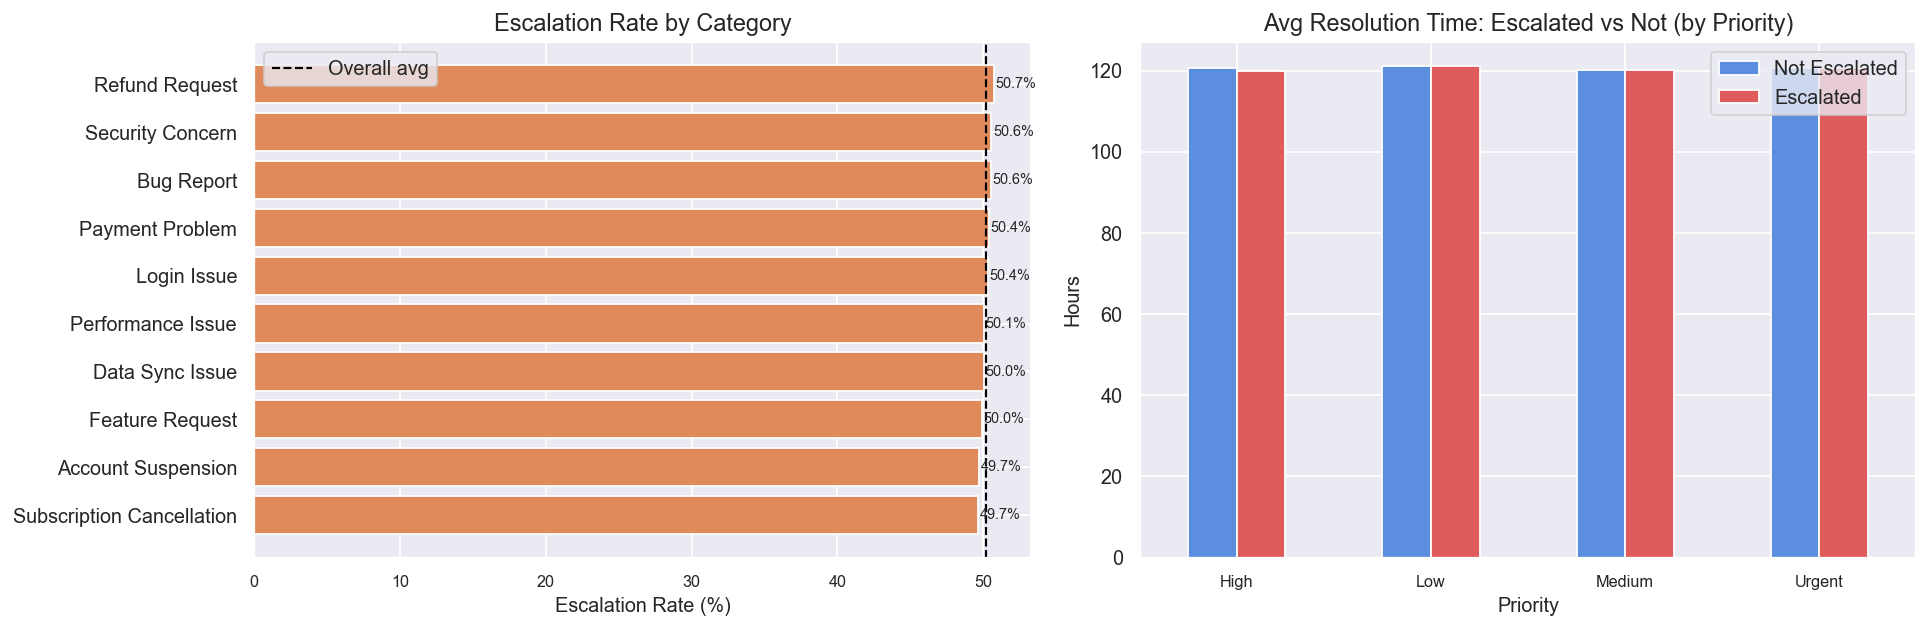

In [9]:
# Visual — escalation rate by category
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Escalation rate by category
esc_cat = df.groupby('category')['escalated'].mean().sort_values(ascending=True) * 100
axes[0].barh(esc_cat.index, esc_cat.values, color='#e08a5c', edgecolor='white')
axes[0].axvline(df['escalated'].mean() * 100, color='black', linestyle='--', linewidth=1.2, label='Overall avg')
axes[0].set_title('Escalation Rate by Category')
axes[0].set_xlabel('Escalation Rate (%)')
axes[0].legend()
for i, v in enumerate(esc_cat.values):
    axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8)

# Resolution time: escalated vs not, by priority
esc_prio = df.groupby(['priority', 'escalated'])['resolution_time_hours'].mean().unstack()
esc_prio.columns = ['Not Escalated', 'Escalated']
esc_prio.plot(kind='bar', ax=axes[1], color=['#5c8ee0', '#e05c5c'], edgecolor='white', rot=0)
axes[1].set_title('Avg Resolution Time: Escalated vs Not (by Priority)')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Hours')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. Response Speed Bucket Analysis

In [10]:
# Distribution of response speed buckets
bucket_order = ['Immediate (<1h)', 'Same Day (<8h)', 'Next Day (<24h)', 'Delayed (>24h)']
bucket_stats = df.groupby('response_speed_bucket', observed=True).agg(
    ticket_count=('ticket_id', 'count'),
    sla_breach_rate=('sla_breached', 'mean'),
    escalation_rate=('escalated', 'mean'),
    avg_resolution_hrs=('resolution_time_hours', 'mean'),
    avg_satisfaction=('customer_satisfaction_score', 'mean')
).round(3)

# Reindex to logical order (only keep buckets that exist)
existing_order = [b for b in bucket_order if b in bucket_stats.index]
bucket_stats = bucket_stats.reindex(existing_order)
bucket_stats['pct_of_tickets'] = (bucket_stats['ticket_count'] / len(df) * 100).round(1)
print(bucket_stats.to_string())

                       ticket_count  sla_breach_rate  escalation_rate  avg_resolution_hrs  avg_satisfaction  pct_of_tickets
response_speed_bucket                                                                                                      
Immediate (<1h)                1379             0.48             0.50              119.93              3.00            0.70
Same Day (<8h)                19723             0.50             0.50              119.89              3.01            9.90
Next Day (<24h)               44449             0.50             0.51              120.35              3.00           22.20
Delayed (>24h)               134449             0.50             0.50              120.70              3.00           67.20


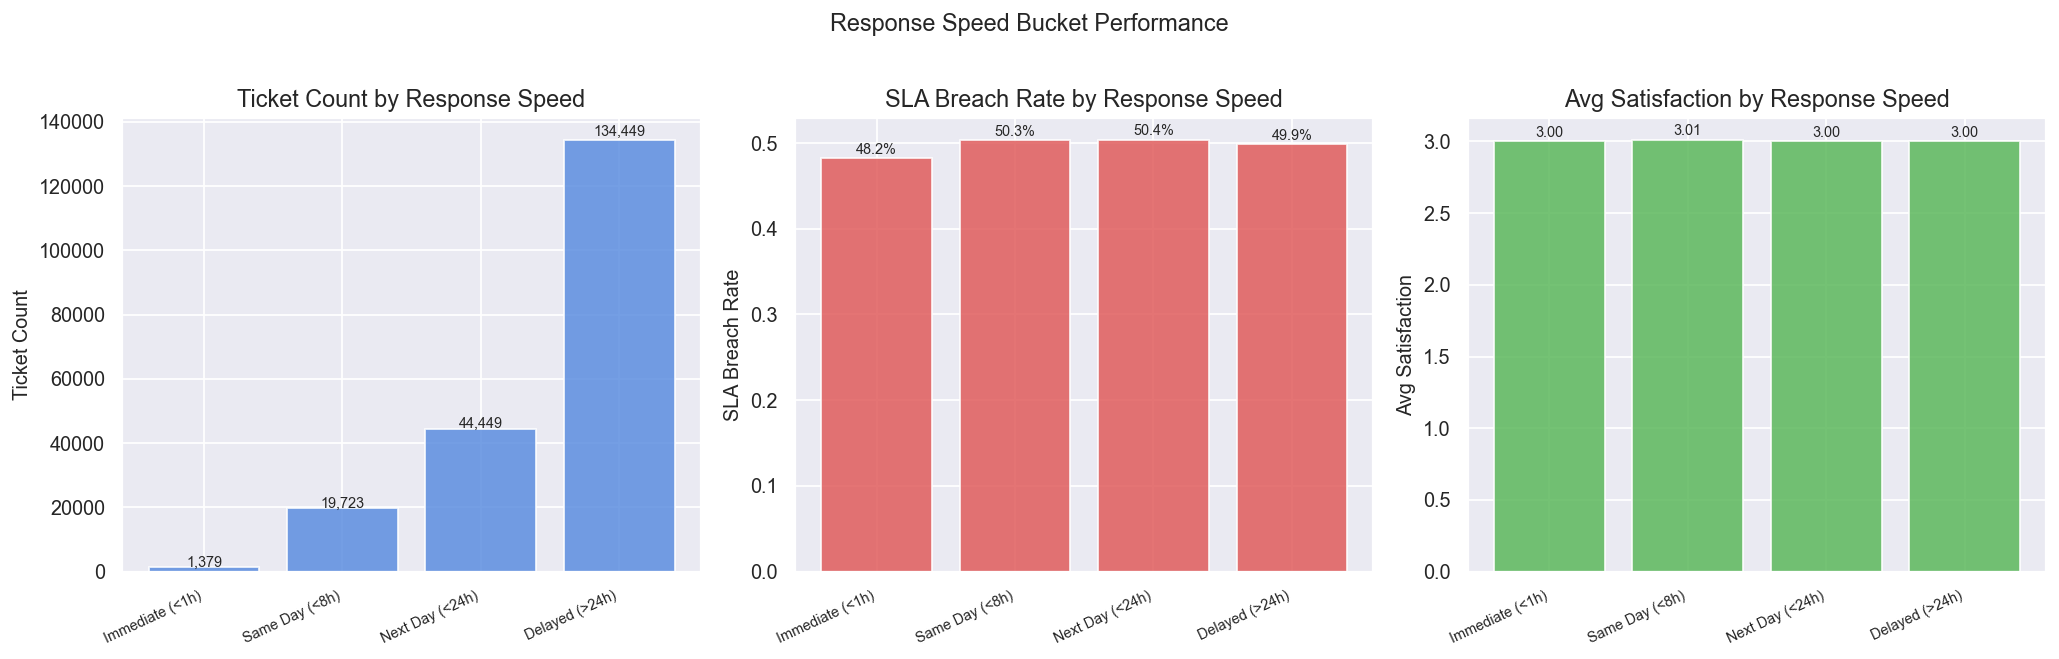

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('ticket_count',    'Ticket Count',        '#5c8ee0'),
    ('sla_breach_rate', 'SLA Breach Rate',     '#e05c5c'),
    ('avg_satisfaction','Avg Satisfaction',    '#5cb85c'),
]

for ax, (metric, label, color) in zip(axes, metrics):
    vals = bucket_stats[metric]
    ax.bar(range(len(vals)), vals.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=25, ha='right', fontsize=8)
    ax.set_title(f'{label} by Response Speed')
    ax.set_ylabel(label)
    for i, v in enumerate(vals.values):
        label_str = f'{v*100:.1f}%' if 'rate' in metric else f'{v:.2f}' if 'sat' in metric else f'{int(v):,}'
        ax.text(i, v * 1.01, label_str, ha='center', fontsize=8)

plt.suptitle('Response Speed Bucket Performance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Outlier Ticket Identification

Outliers = tickets where response time exceeds the 95th percentile.  
These are the tickets most likely to drive customer dissatisfaction.

In [12]:

df['first_response_time_hours'] = pd.to_numeric(df['first_response_time_hours'], errors='coerce')
df['resolution_time_hours'] = pd.to_numeric(df['resolution_time_hours'], errors='coerce')

response_p95 = df['first_response_time_hours'].quantile(0.95)
resolution_p95 = df['resolution_time_hours'].quantile(0.95)

print(f'Response time  P95 threshold : {response_p95:.1f} hrs')
print(f'Resolution time P95 threshold: {resolution_p95:.1f} hrs')

df['response_outlier']   = df['first_response_time_hours']  > response_p95
df['resolution_outlier'] = df['resolution_time_hours']      > resolution_p95
df['double_outlier']     = df['response_outlier'] & df['resolution_outlier']

print(f'\nResponse outliers   : {df["response_outlier"].sum():,} ({df["response_outlier"].mean():.1%})')
print(f'Resolution outliers : {df["resolution_outlier"].sum():,} ({df["resolution_outlier"].mean():.1%})')
print(f'Double outliers     : {df["double_outlier"].sum():,} ({df["double_outlier"].mean():.1%})')

Response time  P95 threshold : 68.5 hrs
Resolution time P95 threshold: 228.0 hrs

Response outliers   : 9,988 (5.0%)
Resolution outliers : 9,999 (5.0%)
Double outliers     : 512 (0.3%)


In [ ]:

print('=== Double Outlier Profile (slowest tickets on both dimensions) ===')

outlier_df = df[df['double_outlier']]

cat_profile = {
    'priority (mode)': outlier_df['priority'].value_counts().index[0],
    'category (mode)': outlier_df['category'].value_counts().index[0],
    'channel (mode)':  outlier_df['channel'].value_counts().index[0],
}

num_profile = outlier_df.agg({
    'sla_breached':                'mean',
    'escalated':                   'mean',
    'customer_satisfaction_score': 'mean',
    'first_response_time_hours':   'mean',
    'resolution_time_hours':       'mean'
}).round(2)

for k, v in cat_profile.items():
    print(f'{k:35s}: {v}')
for k, v in num_profile.items():
    print(f'{k:35s}: {v}')

print('\n=== Top Categories in Double Outlier Tickets ===')
print(outlier_df['category'].value_counts().head(5))

print('\n=== Top Priorities in Double Outlier Tickets ===')
print(outlier_df['priority'].value_counts())

=== Double Outlier Profile (slowest tickets on both dimensions) ===
priority (mode)                    : Low
category (mode)                    : Login Issue
channel (mode)                     : Social Media
sla_breached                       : 0.51
escalated                          : 0.47
customer_satisfaction_score        : 2.99
first_response_time_hours          : 70.22
resolution_time_hours              : 234.02

=== Top Categories in Double Outlier Tickets ===
category
Login Issue                  60
Subscription Cancellation    56
Feature Request              51
Account Suspension           51
Payment Problem              51
Name: count, dtype: int64

=== Top Priorities in Double Outlier Tickets ===
priority
Low       132
Medium    131
High      131
Urgent    118
Name: count, dtype: int64


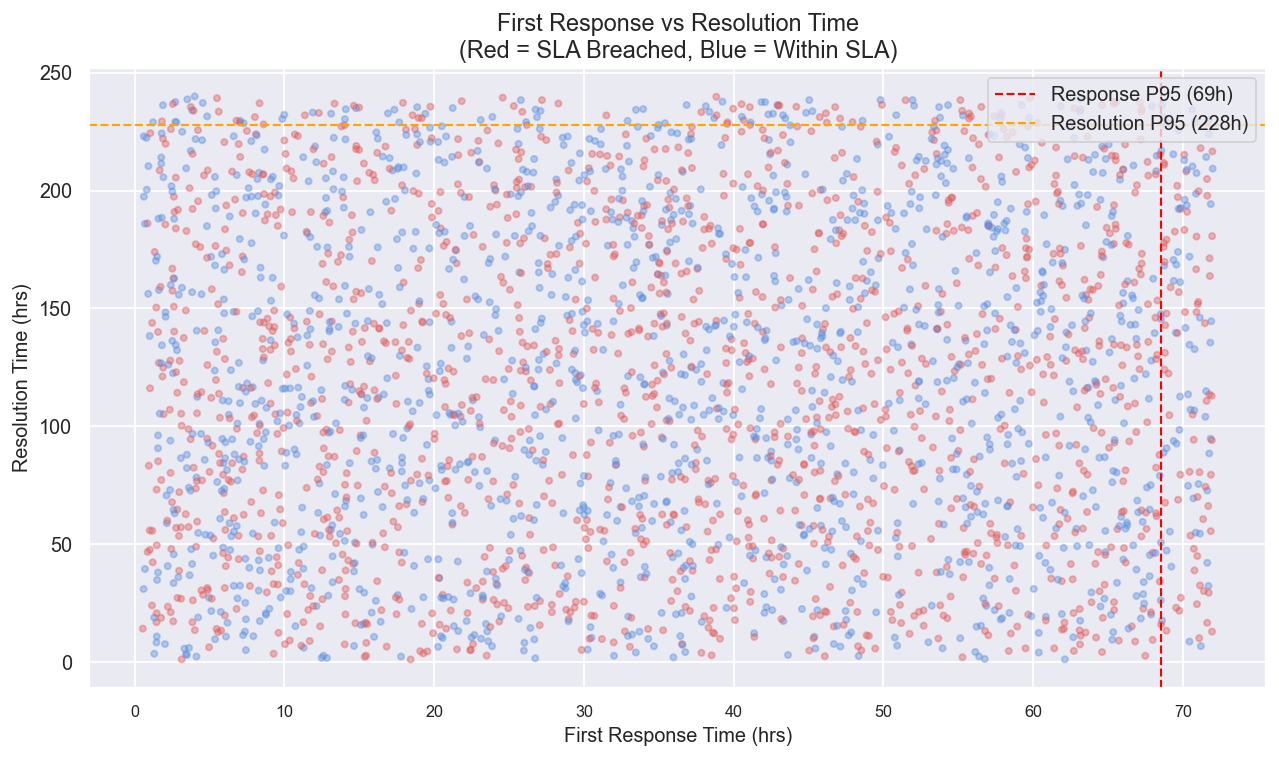

In [17]:
# Scatter — first response vs resolution time, coloured by SLA breach
sample = df.sample(3000, random_state=42)  # sample for plot clarity

fig, ax = plt.subplots(figsize=(10, 6))
colors = sample['sla_breached'].map({True: '#e05c5c', False: '#5c8ee0'})
ax.scatter(sample['first_response_time_hours'], sample['resolution_time_hours'],
           c=colors, alpha=0.4, s=12)
ax.axvline(response_p95, color='red', linestyle='--', linewidth=1.2, label=f'Response P95 ({response_p95:.0f}h)')
ax.axhline(resolution_p95, color='orange', linestyle='--', linewidth=1.2, label=f'Resolution P95 ({resolution_p95:.0f}h)')
ax.set_title('First Response vs Resolution Time\n(Red = SLA Breached, Blue = Within SLA)')
ax.set_xlabel('First Response Time (hrs)')
ax.set_ylabel('Resolution Time (hrs)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Correlation Analysis — What Predicts Longer Resolution?

Encode categorical drivers and compute Pearson correlation with `resolution_time_hours`.

In [18]:
corr_df = df[[
    'resolution_time_hours', 'first_response_time_hours',
    'issue_complexity_score', 'previous_tickets', 'customer_tenure_months',
    'customer_age', 'customer_satisfaction_score',
    'prediction_confidence', 'resolution_sentiment_score'
]].copy()

# Encode binary / categorical
corr_df['sla_breached_int'] = df['sla_breached'].astype(int)
corr_df['escalated_int']    = df['escalated'].astype(int)
corr_df['priority_encoded'] = df['priority'].map({'Low':1,'Medium':2,'High':3,'Urgent':4})

corr_matrix = corr_df.corr()
resolution_corr = corr_matrix['resolution_time_hours'].drop('resolution_time_hours').sort_values()

print('=== Correlation with Resolution Time ===')
print(resolution_corr.round(4))

=== Correlation with Resolution Time ===
customer_satisfaction_score   -0.00
prediction_confidence         -0.00
priority_encoded              -0.00
sla_breached_int              -0.00
customer_age                  -0.00
resolution_sentiment_score    -0.00
escalated_int                 -0.00
previous_tickets              -0.00
customer_tenure_months         0.00
issue_complexity_score         0.00
first_response_time_hours      0.00
Name: resolution_time_hours, dtype: float64


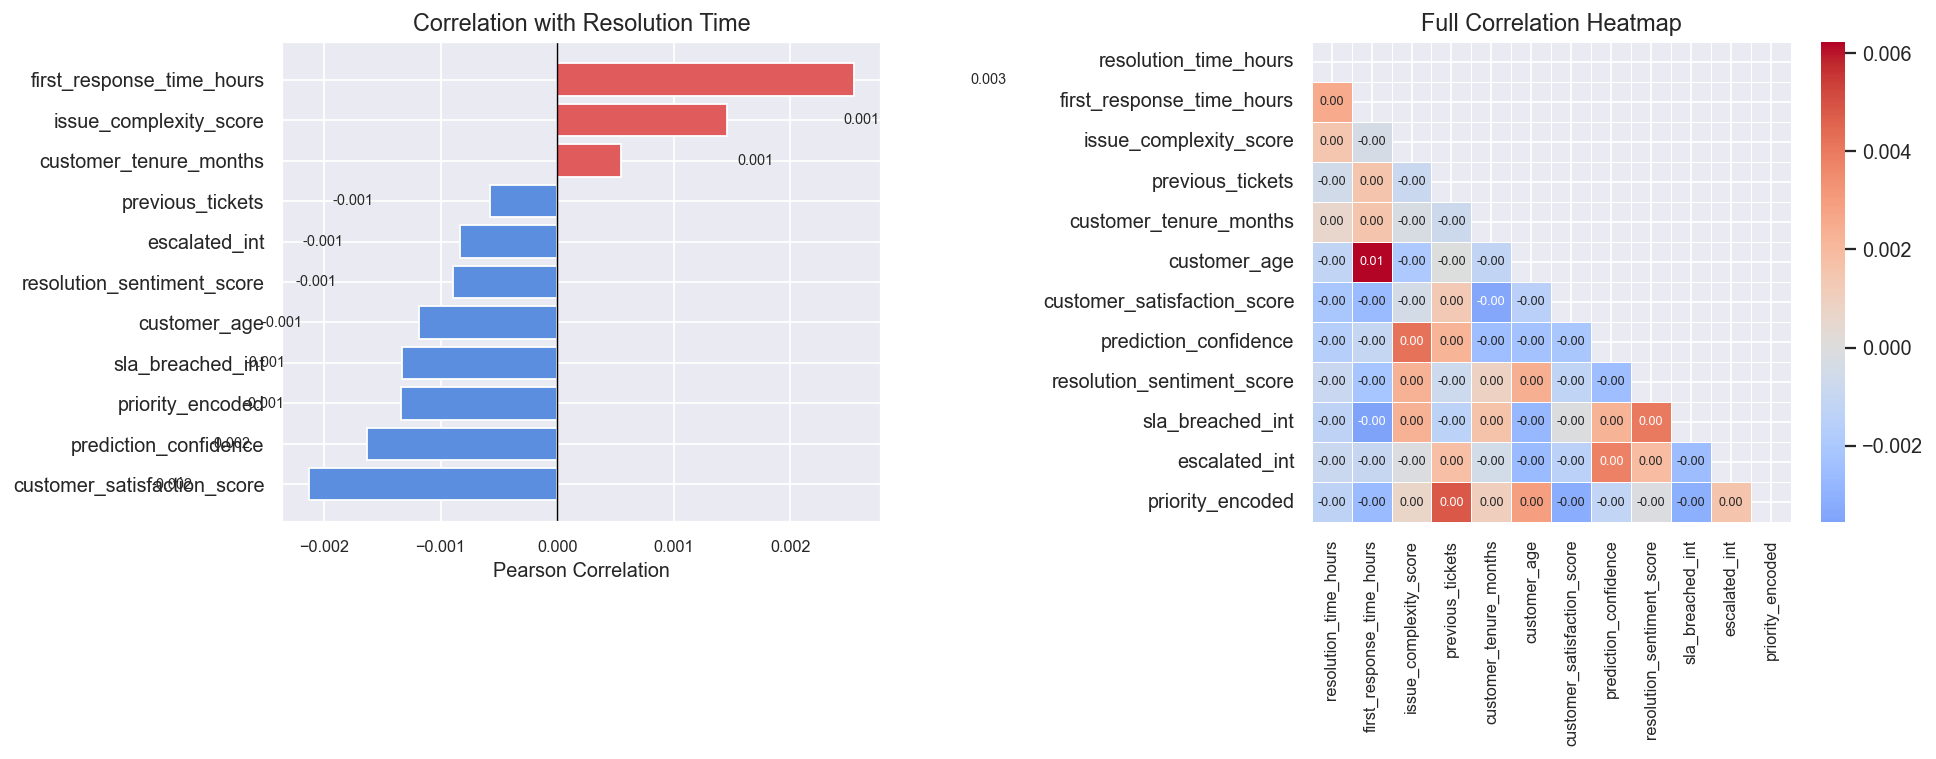

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Correlation bar chart
colors = ['#e05c5c' if v > 0 else '#5c8ee0' for v in resolution_corr.values]
axes[0].barh(resolution_corr.index, resolution_corr.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlation with Resolution Time')
axes[0].set_xlabel('Pearson Correlation')
for i, v in enumerate(resolution_corr.values):
    axes[0].text(v + (0.001 if v >= 0 else -0.001), i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=8)

# Heatmap of full correlation matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=axes[1], annot_kws={'size': 7})
axes[1].set_title('Full Correlation Heatmap')
plt.tight_layout()
plt.show()

---
## 9. Time-Series Trend — Monthly Response & SLA Breach Rate

In [22]:
df['year_month'] = df['ticket_created_date'].dt.to_period('M')

monthly = df.groupby('year_month').agg(
    ticket_volume=('ticket_id', 'count'),
    avg_response_hrs=('first_response_time_hours', 'mean'),
    avg_resolution_hrs=('resolution_time_hours', 'mean'),
    sla_breach_rate=('sla_breached', 'mean'),
    escalation_rate=('escalated', 'mean')
).reset_index()

monthly['year_month_str'] = monthly['year_month'].astype(str)
print(f'Monthly data spans: {monthly["year_month_str"].min()} to {monthly["year_month_str"].max()}')
monthly.tail(6)

Monthly data spans: 2022-01 to 2024-12


,year_month,ticket_volume,avg_response_hrs,avg_resolution_hrs,sla_breach_rate,escalation_rate,year_month_str
30,2024-07,5677,36.31,120.90,0.52,0.50,2024-07
31,2024-08,5672,36.49,120.61,0.50,0.50,2024-08
32,2024-09,5540,37.13,120.30,0.50,0.50,2024-09
33,2024-10,5494,36.51,119.74,0.50,0.50,2024-10
34,2024-11,5423,36.67,121.97,0.50,0.50,2024-11
35,2024-12,5749,36.44,120.23,0.49,0.52,2024-12


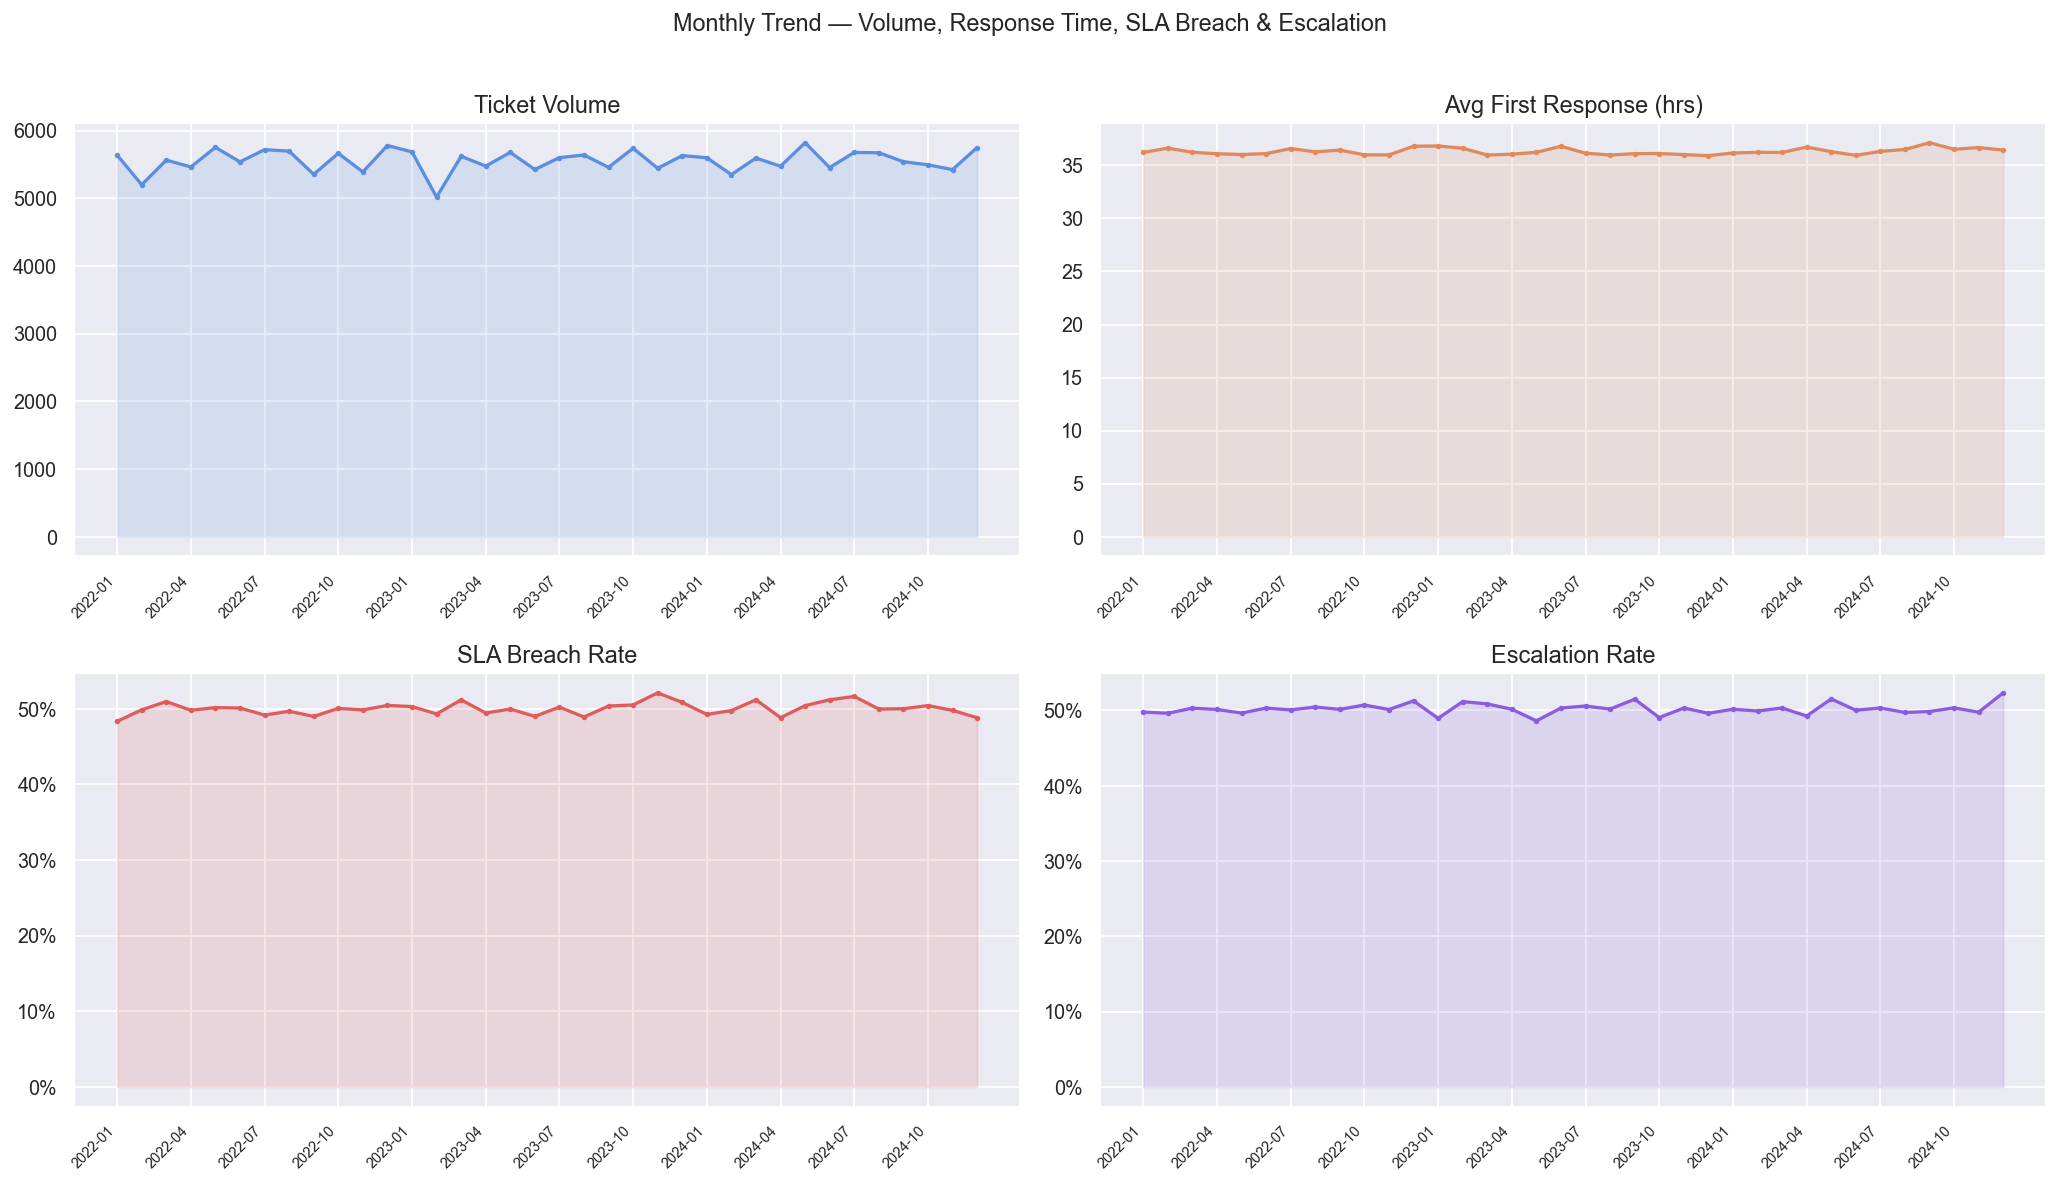

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

x = range(len(monthly))
xtick_step = max(1, len(monthly) // 12)

plots = [
    (axes[0,0], 'ticket_volume',     'Ticket Volume',             '#5c8ee0', False),
    (axes[0,1], 'avg_response_hrs',  'Avg First Response (hrs)',  '#e08a5c', False),
    (axes[1,0], 'sla_breach_rate',   'SLA Breach Rate',           '#e05c5c', True),
    (axes[1,1], 'escalation_rate',   'Escalation Rate',           '#8a5ce0', True),
]

for ax, col, title, color, is_pct in plots:
    ax.plot(x, monthly[col], color=color, linewidth=1.8, marker='o', markersize=2)
    ax.fill_between(x, monthly[col], alpha=0.15, color=color)
    ax.set_title(title)
    ax.set_xticks(x[::xtick_step])
    ax.set_xticklabels(monthly['year_month_str'].iloc[::xtick_step], rotation=45, ha='right', fontsize=8)
    if is_pct:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

plt.suptitle('Monthly Trend — Volume, Response Time, SLA Breach & Escalation', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

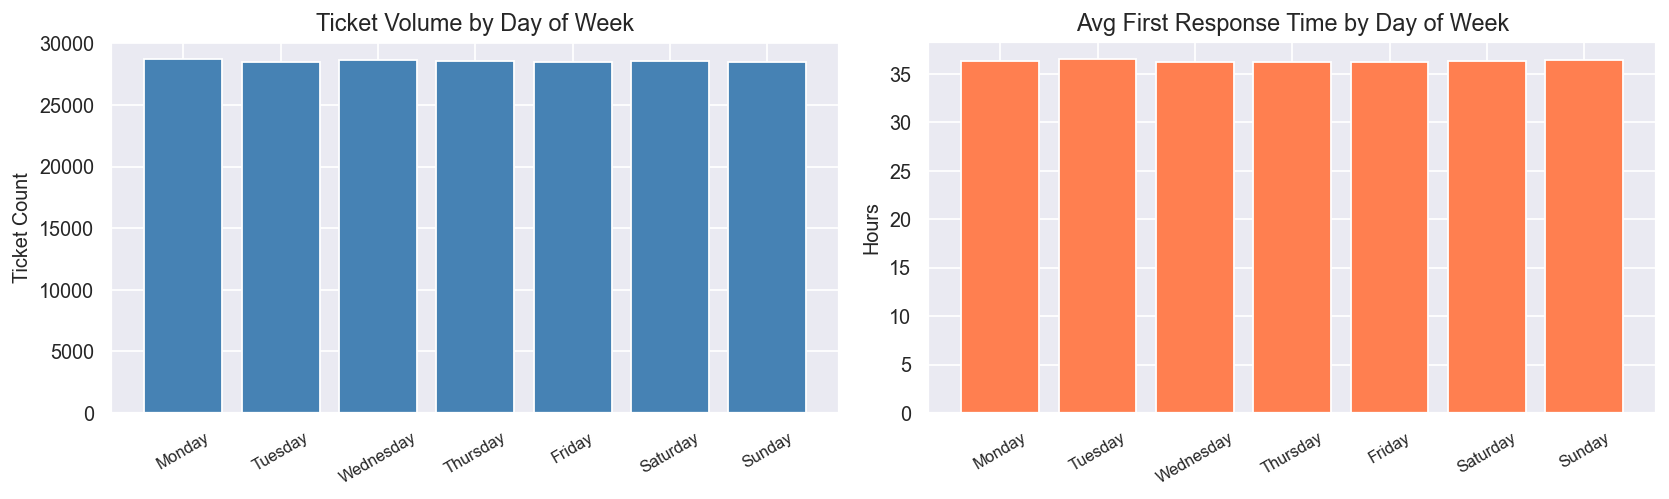

In [26]:
# Day-of-week volume & response pattern
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_stats = df.groupby('created_day_of_week').agg(
    ticket_count=('ticket_id', 'count'),
    avg_response_hrs=('first_response_time_hours', 'mean'),
    sla_breach_rate=('sla_breached', 'mean')
).reindex([d for d in dow_order if d in df['created_day_of_week'].unique()])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(dow_stats.index, dow_stats['ticket_count'], color='steelblue', edgecolor='white')
axes[0].set_title('Ticket Volume by Day of Week')
axes[0].set_ylabel('Ticket Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(dow_stats.index, dow_stats['avg_response_hrs'], color='coral', edgecolor='white')
axes[1].set_title('Avg First Response Time by Day of Week')
axes[1].set_ylabel('Hours')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [27]:
# Risk score — composite of breach, escalation, outlier flags
# Scale: 0 (best) to 3 (highest risk)
df['risk_score'] = (
    df['sla_breached'].astype(int) +
    df['escalated'].astype(int) +
    df['response_outlier'].astype(int)
)

df['risk_label'] = df['risk_score'].map({0: 'Low', 1: 'Medium', 2: 'High', 3: 'Critical'})

print('=== Risk Label Distribution ===')
print(df['risk_label'].value_counts().sort_index())

print('\n=== Risk Label vs Avg Satisfaction ===')
print(df.groupby('risk_label')['customer_satisfaction_score'].mean().round(3))

print('\n=== Risk Label vs Avg Resolution Time ===')
print(df.groupby('risk_label')['resolution_time_hours'].mean().round(2))

=== Risk Label Distribution ===
risk_label
Critical     2437
High        52703
Low         47125
Medium      97735
Name: count, dtype: int64

=== Risk Label vs Avg Satisfaction ===
risk_label
Critical   2.98
High       3.00
Low        3.00
Medium     3.00
Name: customer_satisfaction_score, dtype: float64

=== Risk Label vs Avg Resolution Time ===
risk_label
Critical   122.62
High       120.44
Low        120.86
Medium     120.39
Name: resolution_time_hours, dtype: float64


In [29]:
# Export enriched dataset
new_cols = ['complexity_bucket', 'response_outlier', 'resolution_outlier',
            'double_outlier', 'year_month', 'risk_score', 'risk_label']

# Drop year_month Period type (not CSV-serialisable) — already have created_year/month
export_df = df.drop(columns=['year_month'])

output_path = 'C:/Users/Tarun/OneDrive/Desktop/Project 3/Data Sets/Response_time_enriched.csv'
export_df.to_csv(output_path, index=False)

print(f'Exported → {output_path}')
print(f'Final shape: {export_df.shape}')
print(f'\nNew columns added this phase:')
for c in ['complexity_bucket', 'response_outlier', 'resolution_outlier', 'double_outlier', 'risk_score', 'risk_label']:
    print(f'  {c}')

Exported → C:/Users/Tarun/OneDrive/Desktop/Project 3/Data Sets/Response_time_enriched.csv
Final shape: (200000, 46)

New columns added this phase:
  complexity_bucket
  response_outlier
  resolution_outlier
  double_outlier
  risk_score
  risk_label
